# Day 7 — Baseline Model Training

## Objectives

- Load preprocessed train/test data from Day 6
- Train 3 baseline models:
  - Logistic Regression
  - Random Forest
  - XGBoost
- Evaluate using Accuracy, Precision, Recall, F1-score, and ROC-AUC
- Compare all models
- Select the best baseline model
- Save the best model

In [24]:
import sys
print(sys.executable)

c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.venv\Scripts\python.exe


In [25]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import json

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [27]:
current_directory = Path.cwd()

if (current_directory / "data").exists():
    PROJECT_ROOT = current_directory
elif (current_directory.parent / "data").exists():
    PROJECT_ROOT = current_directory.parent
else:
    raise FileNotFoundError("Could not find project root.")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine


In [28]:
X_train = np.load(PROCESSED_DIR / "X_train_processed.npy")
X_test = np.load(PROCESSED_DIR / "X_test_processed.npy")

y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTrain churn rate:", round(y_train.mean(), 3))
print("Test churn rate :", round(y_test.mean(), 3))

X_train shape: (5616, 50)
X_test shape : (1405, 50)
y_train shape: (5616,)
y_test shape : (1405,)

Train churn rate: 0.264
Test churn rate : 0.265


In [29]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained classifier and return classification metrics.
    """

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1_Score": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }

    print(f"\n{'=' * 50}")
    print(f"Results for: {model_name}")
    print(f"{'=' * 50}")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Stayed", "Churned"]
        )
    )

    print(f"ROC-AUC Score: {metrics['ROC_AUC']:.4f}")

    return metrics, y_pred, y_proba

In [30]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train, y_train)

log_reg_metrics, log_reg_pred, log_reg_proba = evaluate_model(
    log_reg,
    X_test,
    y_test,
    "Logistic Regression"
)


Results for: Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1033
     Churned       0.50      0.77      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.79      0.74      0.75      1405

ROC-AUC Score: 0.8399


In [31]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_metrics, rf_pred, rf_proba = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)


Results for: Random Forest
              precision    recall  f1-score   support

      Stayed       0.88      0.81      0.84      1033
     Churned       0.57      0.69      0.62       372

    accuracy                           0.78      1405
   macro avg       0.72      0.75      0.73      1405
weighted avg       0.80      0.78      0.79      1405

ROC-AUC Score: 0.8411


In [32]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

scale_pos_weight = neg_count / pos_count

print(f"Negative (stayed): {neg_count}")
print(f"Positive (churned): {pos_count}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

Negative (stayed): 4131
Positive (churned): 1485
scale_pos_weight: 2.782


In [33]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_metrics, xgb_pred, xgb_proba = evaluate_model(
    xgb_model,
    X_test,
    y_test,
    "XGBoost"
)


Results for: XGBoost
              precision    recall  f1-score   support

      Stayed       0.89      0.75      0.81      1033
     Churned       0.52      0.74      0.61       372

    accuracy                           0.75      1405
   macro avg       0.70      0.74      0.71      1405
weighted avg       0.79      0.75      0.76      1405

ROC-AUC Score: 0.8393


In [34]:
comparison_df = pd.DataFrame([
    log_reg_metrics,
    rf_metrics,
    xgb_metrics
])

metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

comparison_df[metric_cols] = comparison_df[metric_cols].round(4)

comparison_df = (
    comparison_df
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

print("Model Comparison — Sorted by ROC-AUC")

comparison_df

Model Comparison — Sorted by ROC-AUC


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Random Forest,0.7801,0.5698,0.6909,0.6245,0.8411
1,Logistic Regression,0.7374,0.5026,0.7742,0.6095,0.8399
2,XGBoost,0.7473,0.5160,0.7366,0.6069,0.8393


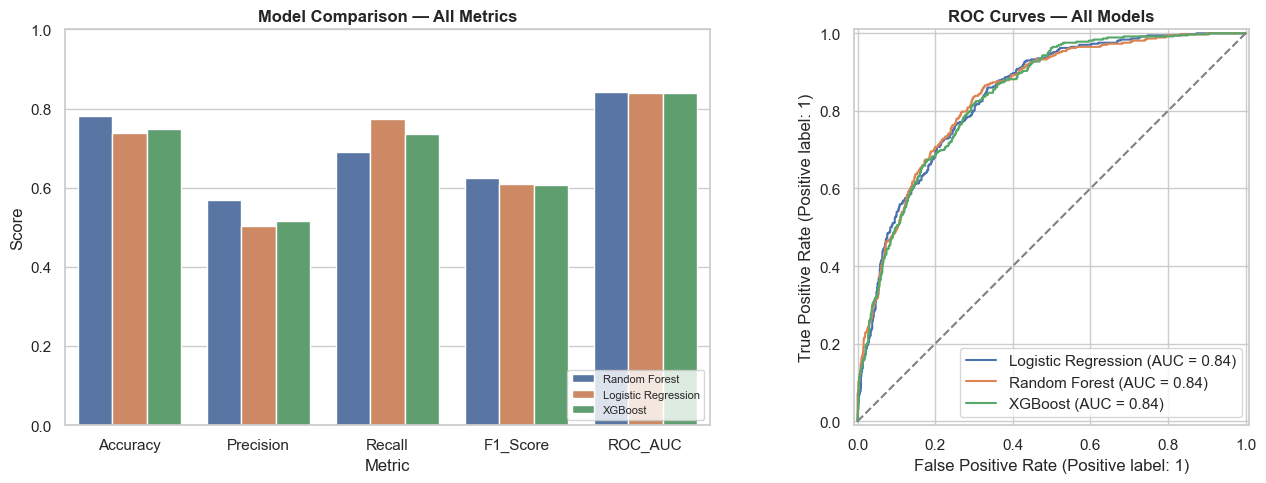

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\08_model_comparison.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of all metrics
comparison_melted = comparison_df.melt(
    id_vars="Model",
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model",
    ax=axes[0]
)

axes[0].set_title("Model Comparison — All Metrics", fontweight="bold")
axes[0].set_ylim(0, 1)
axes[0].legend(loc="lower right", fontsize=8)

# ROC curves
RocCurveDisplay.from_predictions(
    y_test,
    log_reg_proba,
    name="Logistic Regression",
    ax=axes[1]
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_proba,
    name="Random Forest",
    ax=axes[1]
)

RocCurveDisplay.from_predictions(
    y_test,
    xgb_proba,
    name="XGBoost",
    ax=axes[1]
)

axes[1].set_title("ROC Curves — All Models", fontweight="bold")
axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Guess"
)

plt.tight_layout()

output_path = FIGURES_DIR / "08_model_comparison.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", output_path)

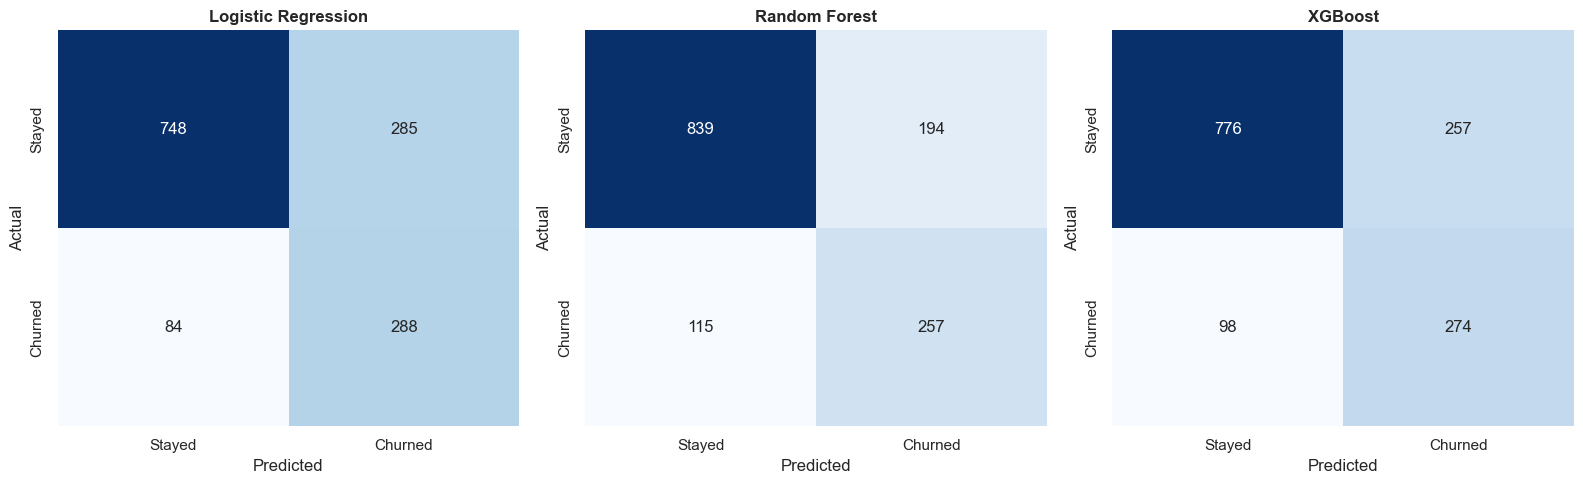

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\09_confusion_matrices.png


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_preds = [
    ("Logistic Regression", log_reg_pred),
    ("Random Forest", rf_pred),
    ("XGBoost", xgb_pred)
]

for ax, (name, preds) in zip(axes, models_preds):

    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Stayed", "Churned"],
        yticklabels=["Stayed", "Churned"],
        ax=ax,
        cbar=False
    )

    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()

output_path = FIGURES_DIR / "09_confusion_matrices.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", output_path)

In [37]:
best_model_name = comparison_df.iloc[0]["Model"]

print(f"Best model based on ROC-AUC: {best_model_name}")

model_map = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

best_model = model_map[best_model_name]

best_model_path = MODELS_DIR / "churn_model.pkl"

joblib.dump(best_model, best_model_path)

print(f"Best model saved to: {best_model_path}")

Best model based on ROC-AUC: Random Forest
Best model saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\models\churn_model.pkl


In [38]:
joblib.dump(
    log_reg,
    MODELS_DIR / "logistic_regression.pkl"
)

joblib.dump(
    rf_model,
    MODELS_DIR / "random_forest.pkl"
)

joblib.dump(
    xgb_model,
    MODELS_DIR / "xgboost_model.pkl"
)

print("All 3 models saved to models/")

All 3 models saved to models/


In [39]:
comparison_df.to_csv(
    REPORTS_DIR / "model_comparison.csv",
    index=False
)

metrics_dict = comparison_df.to_dict(orient="records")

with open(REPORTS_DIR / "model_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

print("Metrics saved successfully.")

Metrics saved successfully.


In [40]:
print("========== DAY 7 MODEL CHECK ==========")

print("Best model:", best_model_name)

print("Best model exists:",
      (MODELS_DIR / "churn_model.pkl").exists())

print("Logistic Regression exists:",
      (MODELS_DIR / "logistic_regression.pkl").exists())

print("Random Forest exists:",
      (MODELS_DIR / "random_forest.pkl").exists())

print("XGBoost exists:",
      (MODELS_DIR / "xgboost_model.pkl").exists())

print("Comparison CSV exists:",
      (REPORTS_DIR / "model_comparison.csv").exists())

print("Metrics JSON exists:",
      (REPORTS_DIR / "model_metrics.json").exists())

print("Comparison figure exists:",
      (FIGURES_DIR / "08_model_comparison.png").exists())

print("Confusion matrix figure exists:",
      (FIGURES_DIR / "09_confusion_matrices.png").exists())

========== DAY 7 MODEL CHECK ==========
Best model: Random Forest
Best model exists: True
Logistic Regression exists: True
Random Forest exists: True
XGBoost exists: True
Comparison CSV exists: True
Metrics JSON exists: True
Comparison figure exists: True
Confusion matrix figure exists: True


In [42]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine


In [44]:
from pathlib import Path
import os
import sys

print("Current directory:")
print(Path.cwd())

print("\nPython path:")
print(sys.path[:5])

print("\nProject files:")
for path in Path.cwd().parent.iterdir():
    print(path)

Current directory:
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\notebooks

Python path:
['c:\\Users\\gurmeet singh\\Projects\\customer-churn-retention-engine', 'C:\\Users\\gurmeet singh\\AppData\\Local\\Programs\\Python\\Python310\\python310.zip', 'C:\\Users\\gurmeet singh\\AppData\\Local\\Programs\\Python\\Python310\\DLLs', 'C:\\Users\\gurmeet singh\\AppData\\Local\\Programs\\Python\\Python310\\lib', 'C:\\Users\\gurmeet singh\\AppData\\Local\\Programs\\Python\\Python310']

Project files:
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.git
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.gitignore
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.pytest_cache
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.venv
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\app
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\data
c:\Users\gurmeet singh\Projects\customer-churn-retention-e

In [45]:
from pathlib import Path

project_root = Path.cwd().parent

print("Project root:", project_root)
print("\nLooking for config.py:")

matches = list(project_root.rglob("config.py"))

for path in matches:
    print(path)

Project root: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine

Looking for config.py:
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.venv\Lib\site-packages\ipykernel\pylab\config.py
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.venv\Lib\site-packages\IPython\core\magics\config.py
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.venv\Lib\site-packages\llvmlite\binding\config.py
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.venv\Lib\site-packages\matplotlib_inline\config.py
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.venv\Lib\site-packages\numba\core\config.py
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.venv\Lib\site-packages\numpy\distutils\command\config.py
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.venv\Lib\site-packages\pandas\_config\config.py
c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.venv\Lib\site-packages\set

In [46]:
from pathlib import Path

project_root = Path.cwd().parent

print("src exists:", (project_root / "src").exists())
print("config.py exists:", (project_root / "src" / "config.py").exists())

if (project_root / "src").exists():
    print("\nFiles inside src:")
    for p in (project_root / "src").iterdir():
        print(p.name)

src exists: True
config.py exists: False

Files inside src:
data_preprocessing.py
feature_engineering.py
train_model.py
__init__.py
__pycache__


In [48]:
import joblib
from pathlib import Path

MODEL_PATH = Path("../models/churn_model.pkl")

best_model = joblib.load(MODEL_PATH)

print("Loaded model from:", MODEL_PATH)
print("Model type:", type(best_model).__name__)

Loaded model from: ..\models\churn_model.pkl
Model type: RandomForestClassifier


In [49]:
PREPROCESSOR_PATH = Path("../models/preprocessor.joblib")

preprocessor = joblib.load(PREPROCESSOR_PATH)

print("Preprocessor loaded successfully")
print("Preprocessor type:", type(preprocessor).__name__)

Preprocessor loaded successfully
Preprocessor type: ColumnTransformer


In [50]:
classifier = best_model

print("Classifier:", type(classifier).__name__)
print("Number of trees:", classifier.n_estimators)

Classifier: RandomForestClassifier
Number of trees: 200


In [51]:
raw_feature_names = list(preprocessor.get_feature_names_out())

clean_feature_names = [
    name.split("__", 1)[1] if "__" in name else name
    for name in raw_feature_names
]

print("Total output features:", len(clean_feature_names))
print()
print("First 10 feature names:")

for name in clean_feature_names[:10]:
    print(" ", name)

Total output features: 50

First 10 feature names:
  SeniorCitizen
  tenure
  MonthlyCharges
  TotalCharges
  AvgMonthlyCharge
  gender_Female
  gender_Male
  Partner_No
  Partner_Yes
  Dependents_No


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_feature_importance_df(classifier, feature_names):
    if hasattr(classifier, "feature_importances_"):
        importance = classifier.feature_importances_
        importance_type = "Feature Importance"
    elif hasattr(classifier, "coef_"):
        importance = np.abs(classifier.coef_[0])
        importance_type = "Absolute Coefficient"
    else:
        raise ValueError(
            "Classifier has neither feature_importances_ nor coef_."
        )

    df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    df = (
        df
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    df.attrs["importance_type"] = importance_type

    return df


importance_df = get_feature_importance_df(
    classifier,
    clean_feature_names
)

importance_type = importance_df.attrs["importance_type"]

print("Importance type:", importance_type)
print()
print("Top 15 features:")

display(importance_df.head(15))

Importance type: Feature Importance

Top 15 features:


,Feature,Importance
0,tenure,0.108590
1,Contract_Month-to-month,0.095957
2,TotalCharges,0.090461
3,MonthlyCharges,0.071263
4,AvgMonthlyCharge,0.070586
5,Contract_Two year,0.053984
6,TechSupport_No,0.044932
7,OnlineSecurity_No,0.044749
8,InternetService_Fiber optic,0.041893
9,PaymentMethod_Electronic check,0.033963


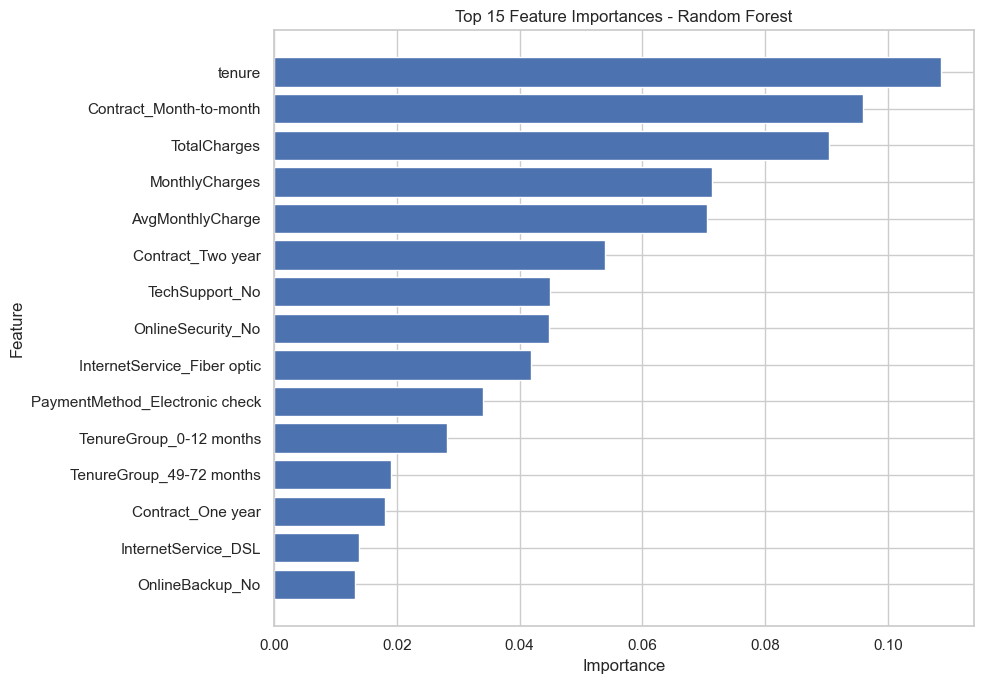

In [53]:
top_features = importance_df.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.tight_layout()

plt.savefig(
    "../reports/figures/13_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
importance_df.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("Saved:")
print("../reports/figures/13_feature_importance.png")
print("../reports/feature_importance.csv")

Saved:
../reports/figures/13_feature_importance.png
../reports/feature_importance.csv


In [57]:
import pandas as pd
import numpy as np

# Recreate the Day 6 feature engineering function
def add_engineered_features(df):
    df = df.copy()

    df["AvgMonthlyCharge"] = np.where(
        df["tenure"] > 0,
        df["TotalCharges"] / df["tenure"],
        df["MonthlyCharges"]
    )

    df["TenureGroup"] = pd.cut(
        df["tenure"],
        bins=[-1, 12, 24, 48, 72],
        labels=[
            "0-12 months",
            "13-24 months",
            "25-48 months",
            "49-72 months"
        ]
    )

    return df


# Reload original train/test data
train_df = pd.read_csv("../data/processed/train_churn_data.csv")
test_df = pd.read_csv("../data/processed/test_churn_data.csv")

# Separate target
X_train_raw = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]

X_test_raw = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

# Apply Day 6 feature engineering
X_train_raw = add_engineered_features(X_train_raw)
X_test_raw = add_engineered_features(X_test_raw)

print("Raw/engineered training shape:", X_train_raw.shape)
print("Raw/engineered test shape:", X_test_raw.shape)
print("Training columns:", len(X_train_raw.columns))

Raw/engineered training shape: (5616, 21)
Raw/engineered test shape: (1405, 21)
Training columns: 21


In [58]:
# Transform raw 21-feature data into the 50 model features
X_train_transformed = preprocessor.transform(X_train_raw)

print("Transformed training shape:", X_train_transformed.shape)

Transformed training shape: (5616, 50)


In [59]:
# Create reproducible SHAP sample
sample_size = min(500, X_train_transformed.shape[0])

rng = np.random.default_rng(42)

sample_idx = rng.choice(
    X_train_transformed.shape[0],
    sample_size,
    replace=False
)

X_sample = X_train_transformed[sample_idx]

print("SHAP sample shape:", X_sample.shape)

SHAP sample shape: (500, 50)


In [ ]:
import shap

explainer = shap.TreeExplainer(classifier)

shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated.")

if isinstance(shap_values, list):
    print("Class 0 shape:", shap_values[0].shape)
    print("Class 1 shapeSHAP shape: (500, 50, 2):", shap_values[1].shape)
else:
    print("SHAP output shape:", shap_values.shape)

SHAP values calculated.
SHAP output shape: (500, 50, 2)


In [62]:
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values

print("Churn SHAP shape:", shap_values_churn.shape)

Churn SHAP shape: (500, 50, 2)


In [63]:
print("Type:", type(shap_values))
print("Shape:", shap_values.shape)

print("\nExplainer expected value:")
print(explainer.expected_value)

print("\nClassifier:")
print(classifier)

print("\nX_sample shape:")
print(X_sample.shape)

Type: <class 'numpy.ndarray'>
Shape: (500, 50, 2)

Explainer expected value:
[0.49996353 0.50003647]

Classifier:
RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

X_sample shape:
(500, 50)


In [64]:
print("Number of model features:", classifier.n_features_in_)
print("Number of feature names:", len(clean_feature_names))

Number of model features: 50
Number of feature names: 50


In [65]:
print("SHAP values:")
print(shap_values[:2])

SHAP values:
[[[ 2.67760555e-03 -2.67760555e-03]
  [-1.33758185e-02  1.33758185e-02]
  [ 6.85692242e-03 -6.85692242e-03]
  [ 1.86092770e-02 -1.86092770e-02]
  [ 5.39319377e-03 -5.39319377e-03]
  [ 2.85702033e-03 -2.85702033e-03]
  [ 2.34915551e-03 -2.34915551e-03]
  [ 2.70125613e-03 -2.70125613e-03]
  [ 3.19386497e-03 -3.19386497e-03]
  [ 1.42965044e-02 -1.42965044e-02]
  [ 1.60303924e-02 -1.60303924e-02]
  [ 6.56014772e-04 -6.56014772e-04]
  [ 1.12891367e-03 -1.12891367e-03]
  [-4.72489178e-04  4.72489178e-04]
  [ 4.65935156e-04 -4.65935156e-04]
  [ 1.50863026e-04 -1.50863026e-04]
  [-5.54346654e-03  5.54346654e-03]
  [-3.28851026e-02  3.28851026e-02]
  [-4.31855187e-03  4.31855187e-03]
  [-2.39662034e-02  2.39662034e-02]
  [-3.79184217e-03  3.79184217e-03]
  [-6.11469901e-03  6.11469901e-03]
  [-2.48560241e-03  2.48560241e-03]
  [-3.34863299e-03  3.34863299e-03]
  [-4.55002964e-03  4.55002964e-03]
  [ 4.09497970e-03 -4.09497970e-03]
  [-3.90430195e-03  3.90430195e-03]
  [ 4.96559156e

In [66]:
shap_values_churn = shap_values[:, :, 1]

print("Original SHAP shape:", shap_values.shape)
print("Churn SHAP shape:", shap_values_churn.shape)

Original SHAP shape: (500, 50, 2)
Churn SHAP shape: (500, 50)


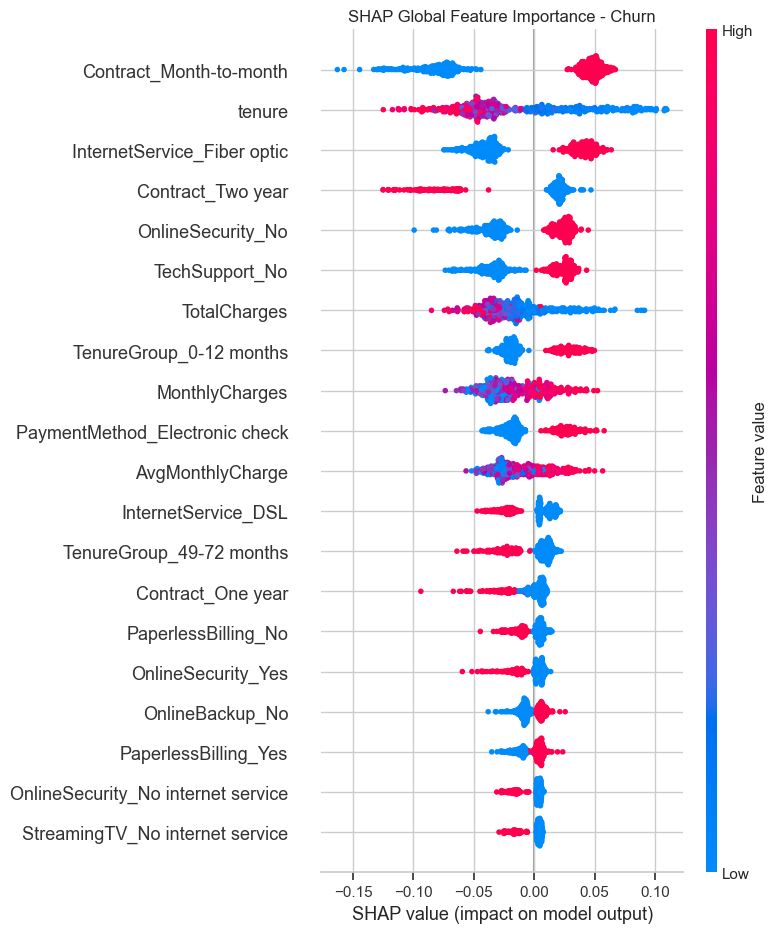

In [67]:
shap.summary_plot(
    shap_values_churn,
    X_sample,
    feature_names=clean_feature_names,
    show=False
)

plt.title("SHAP Global Feature Importance - Churn")
plt.tight_layout()

plt.savefig(
    "../reports/figures/14_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
shap_importance_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Mean_Absolute_SHAP": np.abs(shap_values_churn).mean(axis=0)
})

shap_importance_df = (
    shap_importance_df
    .sort_values("Mean_Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_df.head(15))

,Feature,Mean_Absolute_SHAP
0,Contract_Month-to-month,0.063525
1,tenure,0.046352
2,InternetService_Fiber optic,0.041329
3,Contract_Two year,0.035323
4,OnlineSecurity_No,0.030067
5,TechSupport_No,0.029649
6,TotalCharges,0.027407
7,TenureGroup_0-12 months,0.023063
8,MonthlyCharges,0.022634
9,PaymentMethod_Electronic check,0.022230


In [69]:
shap_importance_df.to_csv(
    "../reports/shap_global_importance.csv",
    index=False
)

print("Saved: ../reports/figures/14_shap_summary.png")
print("Saved: ../reports/shap_global_importance.csv")

Saved: ../reports/figures/14_shap_summary.png
Saved: ../reports/shap_global_importance.csv


In [70]:
X_test_transformed = preprocessor.transform(X_test_raw)

print("Test transformed shape:", X_test_transformed.shape)

Test transformed shape: (1405, 50)


In [71]:
test_probabilities = classifier.predict_proba(X_test_transformed)[:, 1]

highest_risk_idx = np.argmax(test_probabilities)
highest_risk_probability = test_probabilities[highest_risk_idx]

print("Highest-risk customer index:", highest_risk_idx)
print(
    "Churn probability:",
    round(highest_risk_probability * 100, 2),
    "%"
)

Highest-risk customer index: 830
Churn probability: 94.73 %


In [72]:
highest_risk_customer = X_test_raw.iloc[highest_risk_idx]

display(highest_risk_customer.to_frame(name="Value"))

,Value
gender,Female
SeniorCitizen,1
Partner,Yes
Dependents,No
tenure,1
PhoneService,Yes
MultipleLines,Yes
InternetService,Fiber optic
OnlineSecurity,No
OnlineBackup,No


In [73]:
X_customer = X_test_transformed[highest_risk_idx].reshape(1, -1)

individual_shap = explainer.shap_values(X_customer)

if individual_shap.ndim == 3:
    individual_shap_churn = individual_shap[:, :, 1][0]
else:
    individual_shap_churn = individual_shap[0]

print("Individual SHAP shape:", individual_shap_churn.shape)

Individual SHAP shape: (50,)


In [74]:
individual_explanation = pd.DataFrame({
    "Feature": clean_feature_names,
    "SHAP_Value": individual_shap_churn,
    "Absolute_SHAP": np.abs(individual_shap_churn)
})

individual_explanation = (
    individual_explanation
    .sort_values("Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)

display(individual_explanation.head(15))

,Feature,SHAP_Value,Absolute_SHAP
0,tenure,0.061790,0.061790
1,Contract_Month-to-month,0.048899,0.048899
2,InternetService_Fiber optic,0.045190,0.045190
3,TechSupport_No,0.027890,0.027890
4,TenureGroup_0-12 months,0.027212,0.027212
5,OnlineSecurity_No,0.024917,0.024917
6,Contract_Two year,0.022714,0.022714
7,AvgMonthlyCharge,0.021664,0.021664
8,PaymentMethod_Electronic check,0.020278,0.020278
9,TotalCharges,0.017597,0.017597


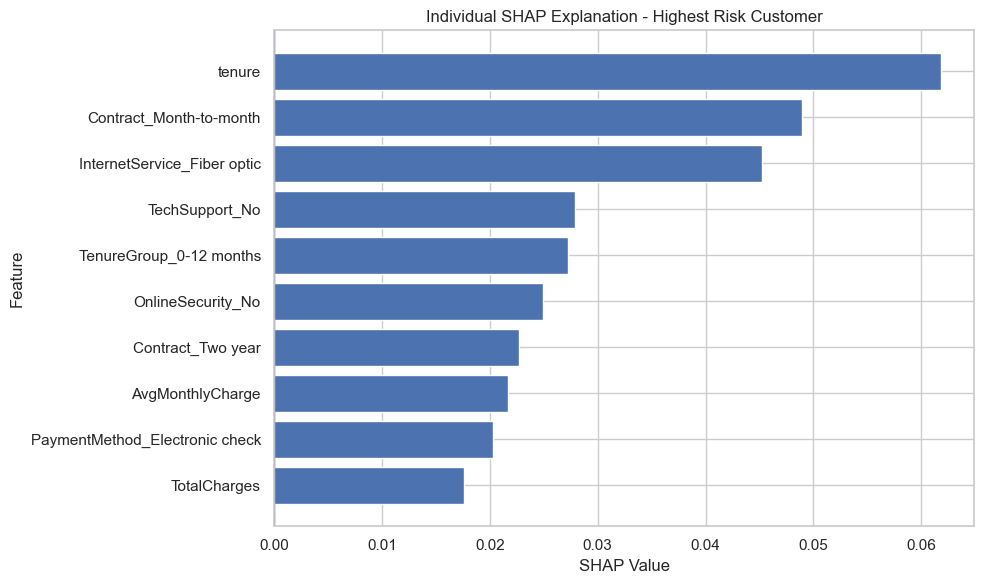

In [75]:
top_individual = (
    individual_explanation
    .head(10)
    .sort_values("SHAP_Value")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_individual["Feature"],
    top_individual["SHAP_Value"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title("Individual SHAP Explanation - Highest Risk Customer")

plt.tight_layout()

plt.savefig(
    "../reports/figures/15_shap_individual_explanation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
individual_explanation.head(15).to_csv(
    "../reports/day8_individual_shap_explanation.csv",
    index=False
)

print("Saved:")
print("../reports/figures/15_shap_individual_explanation.png")
print("../reports/day8_individual_shap_explanation.csv")

Saved:
../reports/figures/15_shap_individual_explanation.png
../reports/day8_individual_shap_explanation.csv


In [77]:
from src.recommendations import (
    get_retention_recommendations,
    get_risk_level,
    build_customer_report
)

example_customer = {
    "Contract": "Month-to-month",
    "InternetService": "Fiber optic",
    "MonthlyCharges": 85.0,
    "tenure": 8,
    "TechSupport": "No",
    "OnlineSecurity": "No",
    "PaymentMethod": "Electronic check"
}

probability = 0.82

report = build_customer_report(
    example_customer,
    probability
)

print("Churn probability:", report["churn_probability"])
print("Risk level:", report["risk_level"])
print("\nRecommendations:")

for recommendation in report["recommendations"]:
    print("-", recommendation)

Churn probability: 0.82
Risk level: High Risk

Recommendations:
- Offer a discount or incentive to move the customer to a one-year or two-year contract.
- Prioritize this customer for proactive retention outreach because the month-to-month fiber optic segment has elevated churn risk.
- Offer a personalized discount or service bundle to reduce the customer's monthly cost burden.
- Provide onboarding support and an early-loyalty incentive to strengthen customer engagement.
- Offer a free technical-support trial to increase service engagement.
- Offer a discounted online-security add-on.
- Encourage migration to automatic payment methods for a more convenient billing experience.


In [78]:
from pathlib import Path
import json

from src.recommendations import build_customer_report

# Convert the highest-risk customer into a dictionary
customer_dict = highest_risk_customer.to_dict()

# Remove engineered feature if desired; the recommendation rules
# only need the original customer information
customer_dict.pop("AvgMonthlyCharge", None)
customer_dict.pop("TenureGroup", None)

# Build report using the actual model probability
actual_customer_report = build_customer_report(
    customer_dict,
    float(highest_risk_probability)
)

print(json.dumps(actual_customer_report, indent=4))

{
    "churn_probability": 0.9473,
    "risk_level": "High Risk",
    "recommendations": [
        "Offer a discount or incentive to move the customer to a one-year or two-year contract.",
        "Prioritize this customer for proactive retention outreach because the month-to-month fiber optic segment has elevated churn risk.",
        "Offer a personalized discount or service bundle to reduce the customer's monthly cost burden.",
        "Provide onboarding support and an early-loyalty incentive to strengthen customer engagement.",
        "Offer a free technical-support trial to increase service engagement.",
        "Offer a discounted online-security add-on.",
        "Encourage migration to automatic payment methods for a more convenient billing experience."
    ]
}


In [79]:
report_path = Path("../reports/day8_example_customer_explanation.json")

with open(report_path, "w", encoding="utf-8") as file:
    json.dump(
        {
            "customer": customer_dict,
            "model_explanation": actual_customer_report,
            "top_shap_features": individual_explanation.head(15).to_dict(
                orient="records"
            )
        },
        file,
        indent=4
    )

print("Saved:", report_path)

Saved: ..\reports\day8_example_customer_explanation.json
